# Методы анализа данных ЛР №3. 

Размер датасета: (139, 13)

Первые строки:
       Country         Region  Flaccid Length (cm)  Erect Length (cm)  \
0  Afghanistan   Central Asia                  9.5              13.69   
1      Albania         Europe                  9.8              14.19   
2      Algeria         Africa                  9.9              14.49   
3       Angola         Africa                 10.0              15.73   
4    Argentina  South America                  9.4              14.88   

   Flaccid Circumference (cm)  Erect Circumference (cm)  Flaccid Volume (cm³)  \
0                         9.1                     11.42                 62.60   
1                         9.7                     12.16                 73.38   
2                         8.9                     10.97                 62.40   
3                         9.6                     11.82                 73.34   
4                         8.9                     11.45                 59.25   

   Erect Volume (cm³)  Growth L

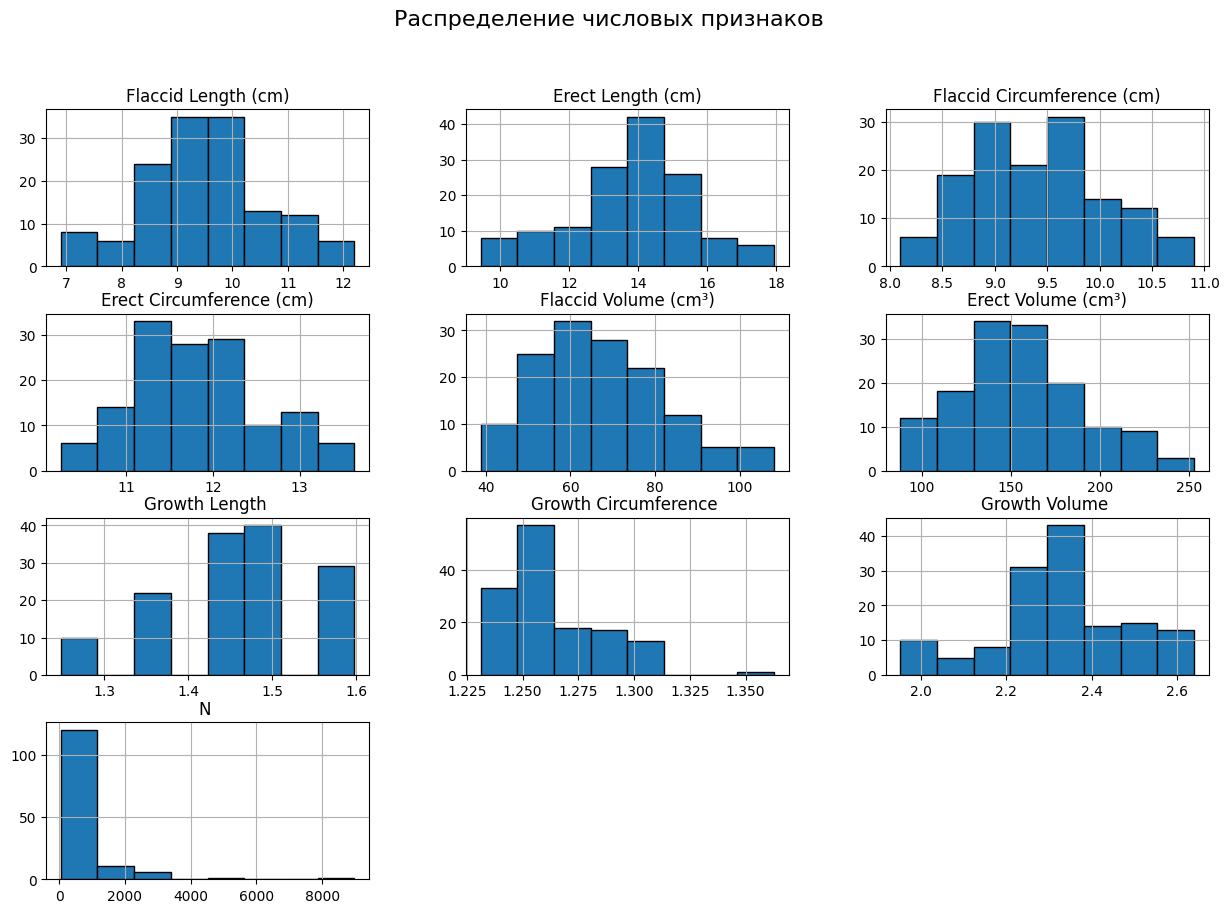

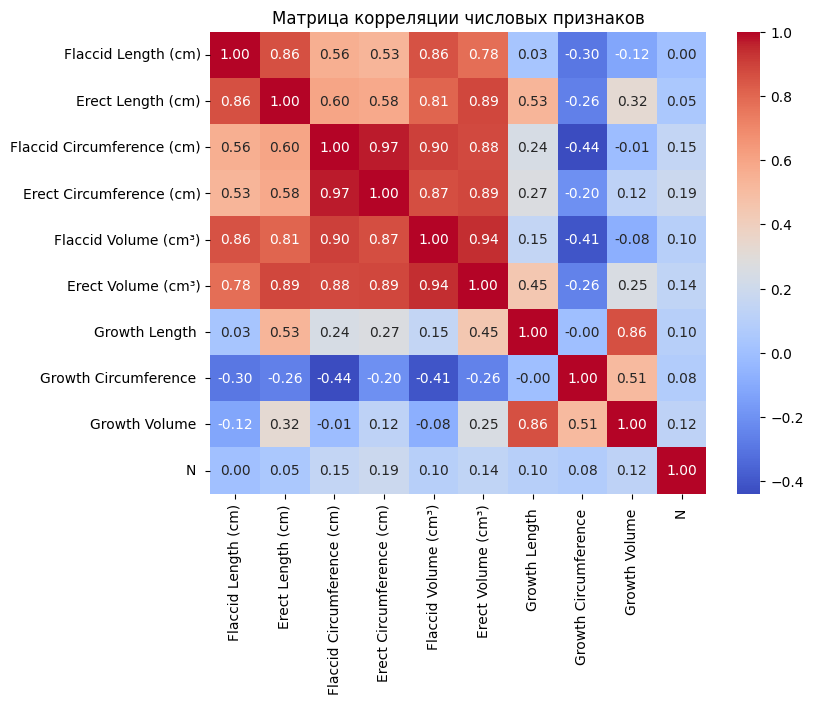

In [10]:
import pandas as pd
import math
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis, normaltest
import seaborn as sns
import numpy as np

# ВАЖНО: возможно понадобится encoding='latin1' или encoding='cp1252'!
df = pd.read_csv("Male Genital Dataset.csv", encoding='latin1')

# Обработка пропусков по числовым столбцам
numeric_cols = df.select_dtypes(include=[np.number]).columns

# Заполнение пропусков средним
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].mean())

print("Размер датасета:", df.shape)
print("\nПервые строки:")
print(df.head())
print("\nИнформация о данных:")
print(df.info())
print("\nОписание признаков:")
print(df.describe())
print("\nКоличество пропусков:")
print(df.isnull().sum())

# Асимметрия и эксцесс
data = {
    'Параметр': [],
    'Асимметрия': [],
    'Эксцесс': []
}
for col in numeric_cols:
    skew_val = skew(df[col].dropna())
    kurt_val = kurtosis(df[col].dropna())
    data['Параметр'].append(col)
    data['Асимметрия'].append(skew_val)
    data['Эксцесс'].append(kurt_val)
summary_df = pd.DataFrame(data)
print(summary_df)

print("\nПроверка нормальности распределения (тест Д’Агостино-Пирсона):")
for col in numeric_cols:
    stat, p = normaltest(df[col].dropna())
    print(f"{col}: статистика={stat:.4f}, p-значение={p:.4f}")
    if p > 0.05:
        print(" → распределение близко к нормальному\n")
    else:
        print(" → распределение отличается от нормального\n")

# Гистограммы признаков
count_of_bins = int(1 + 3.322*math.log10(df.shape[0]))
df[numeric_cols].hist(bins=count_of_bins, figsize=(15, 10), edgecolor="black")
plt.suptitle("Распределение числовых признаков", fontsize=16)
plt.show()

# Корреляционный анализ
plt.figure(figsize=(8,6))
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Матрица корреляции числовых признаков")
plt.show()


Возможные скрытые факторы
- Можно выделить общий размерный фактор, влияющий одновременно на все основные длины, объемы и окружности: высокая корреляция между размерными признаками в разных состояниях (покой/эрекция) свидетельствует о наличии единой размерной компоненты.

- Показано, что изменчивость между «Growth Length», «Growth Circumference», «Growth Volume» и основными размерами не одинакова: ростовые величины не всегда сильно коррелируют с абсолютными показателями, а значит, возможно наличие отдельных биологических или этнических факторов, определяющих потенциал именно прироста, а не абсолютных величин.

- Наличие набора почти независимых корреляций между N (размер выборки) и основными параметрами намекает, что латентные эффекты (например, методология измерений, региональные или возрастные различия испытуемых) не влияют существенно на размерные параметры напрямую, либо их влияние «замаскировано» другими переменными.

- Самостоятельный фактор может определять исключительно окружности и объемы (по отношению к длинам), так как корреляция между длинами и окружностями ниже, чем взаимная корреляция внутри групп «длина» или «окружность/объем».

Первые строки стандартизированных данных:
    Flaccid Length (cm)  Erect Length (cm)  Flaccid Circumference (cm)  \
0            -0.003968          -0.093595                   -0.456666   
1             0.271836           0.187878                    0.502678   
2             0.363771           0.356761                   -0.776447   
3             0.455706           1.054812                    0.342787   
4            -0.095903           0.576309                   -0.776447   

   Erect Circumference (cm)  Flaccid Volume (cm³)  Erect Volume (cm³)  \
0                 -0.582514             -0.329239           -0.414102   
1                  0.441190              0.396205            0.295729   
2                 -1.205038             -0.342698           -0.508784   
3                 -0.029161              0.393513            0.521597   
4                 -0.541013             -0.554678           -0.038796   

   Growth Length   Growth Circumference   Growth Volume         N   
0       -0

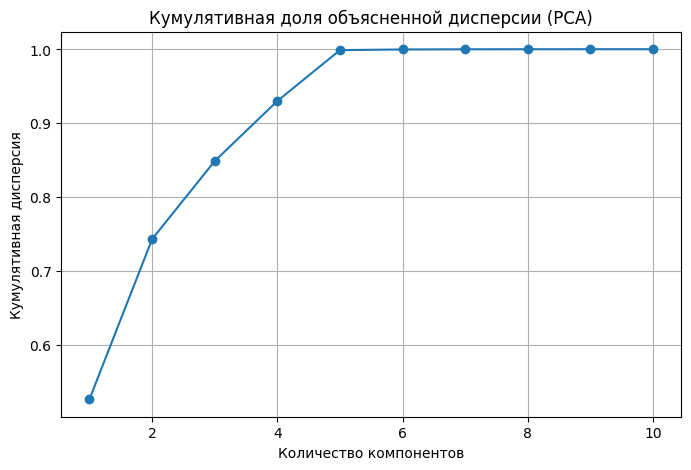


Загрузка переменных по компонентам (PCA):
                                 PC1       PC2       PC3       PC4       PC5  \
Flaccid Length (cm)         0.351109 -0.166682 -0.197176  0.430633  0.375658   
Erect Length (cm)           0.384492  0.130155 -0.261478  0.140989  0.372930   
Flaccid Circumference (cm)  0.393464 -0.099141  0.187639 -0.202075 -0.366398   
Erect Circumference (cm)    0.383531 -0.000446  0.249794 -0.018470 -0.479350   
Flaccid Volume (cm³)        0.421162 -0.152072  0.023776  0.118608 -0.041621   
Erect Volume (cm³)          0.430952  0.074225  0.000381  0.067290 -0.057255   
Growth Length               0.170446  0.547545 -0.183406 -0.434870  0.111609   
Growth Circumference       -0.164535  0.389183  0.159918  0.737568 -0.296605   
Growth Volume               0.063286  0.669510 -0.075727  0.004510 -0.053258   
N                           0.061252  0.131534  0.854186 -0.042035  0.497496   

                                 PC6       PC7       PC8       PC9      PC10

In [11]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA, FactorAnalysis

# --- 1. Стандартизация признаков ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[numeric_cols])
X_scaled_df = pd.DataFrame(X_scaled, columns=numeric_cols)
print("Первые строки стандартизированных данных:\n", X_scaled_df.head())

# --- 2. Метод главных компонент (PCA) ---
pca = PCA()
X_pca = pca.fit_transform(X_scaled)
explained = np.cumsum(pca.explained_variance_ratio_)

print("\nДоля объясненной дисперсии по компонентам:")
for i, var in enumerate(pca.explained_variance_ratio_):
    print(f"Компонента {i+1}: {var:.3f} (кумулятивно: {explained[i]:.3f})")

plt.figure(figsize=(8,5))
plt.plot(range(1, len(numeric_cols)+1), explained, marker='o')
plt.title('Кумулятивная доля объясненной дисперсии (PCA)')
plt.xlabel('Количество компонентов')
plt.ylabel('Кумулятивная дисперсия')
plt.grid()
plt.show()

loadings = pd.DataFrame(pca.components_.T, index=numeric_cols, columns=[f'PC{i+1}' for i in range(len(numeric_cols))])
print("\nЗагрузка переменных по компонентам (PCA):")
print(loadings)

# --- 3. Метод главных факторов (Factor Analysis) ---
fa = FactorAnalysis(n_components=2)  # Число факторов выбирается по результатам PCA или критерию Кайзера
X_fa = fa.fit_transform(X_scaled)

fa_loadings = pd.DataFrame(fa.components_.T, index=numeric_cols, columns=[f'Factor{i+1}' for i in range(fa.n_components)])
print("\nЗагрузка переменных по факторам (FA):")
print(fa_loadings)


KMO (целая модель): 0.495
Тест Бартлетта: chi^2=4677.181, p-value=0.0000


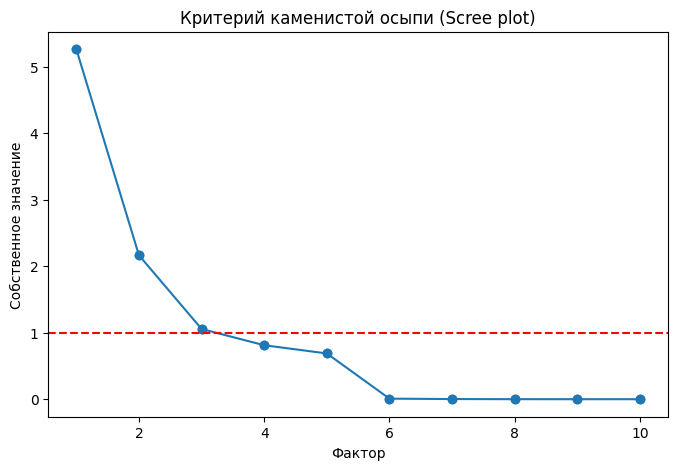

Количество факторов по критерию Кайзера: 3

Факторные нагрузки (после вращения varimax):
                                   0         1         2
Flaccid Length (cm)         0.935940  0.105410 -0.136886
Erect Length (cm)           0.938087  0.176016  0.321719
Flaccid Circumference (cm)  0.505486  0.861348 -0.093981
Erect Circumference (cm)    0.453411  0.859668  0.040806
Flaccid Volume (cm³)        0.810890  0.567752 -0.141494
Erect Volume (cm³)          0.772960  0.599259  0.204219
Growth Length               0.206341  0.214092  0.776210
Growth Circumference       -0.321068 -0.180432  0.370983
Growth Volume              -0.014114  0.095264  1.028799
N                          -0.019375  0.204757  0.106218


In [13]:
from factor_analyzer import FactorAnalyzer, calculate_kmo, calculate_bartlett_sphericity

# 2. Критерий КМО (KMO) и Бартлетта
kmo_all, kmo_model = calculate_kmo(X_scaled)
print(f"KMO (целая модель): {kmo_model:.3f}")
bartlett_chi2, bartlett_p = calculate_bartlett_sphericity(X_scaled)
print(f"Тест Бартлетта: chi^2={bartlett_chi2:.3f}, p-value={bartlett_p:.4f}")

# 3. Критерий каменистой осыпи и Кайзера (график собственных значений + критерий >1)
fa = FactorAnalyzer(rotation=None)
fa.fit(X_scaled)
ev, v = fa.get_eigenvalues()

plt.figure(figsize=(8,5))
plt.scatter(range(1, X_scaled.shape[1]+1), ev)
plt.plot(range(1, X_scaled.shape[1]+1), ev, marker='o')
plt.axhline(1, color='r', linestyle='--')
plt.title('Критерий каменистой осыпи (Scree plot)')
plt.xlabel('Фактор')
plt.ylabel('Собственное значение')
plt.show()

num_factors = sum(ev > 1)
print(f"Количество факторов по критерию Кайзера: {num_factors}")

# 4. Факторный анализ с вращением (например, Варимакс)
fa = FactorAnalyzer(n_factors=num_factors, rotation='varimax')
fa.fit(X_scaled)
loadings = pd.DataFrame(fa.loadings_, index=numeric_cols)
print("\nФакторные нагрузки (после вращения varimax):")
print(loadings)

# Можно также попробовать rotation='promax' (облик, если перемешаны факторы)
